In [1]:
# Notebooks live in Notebooks/, but every data path is relative to the repo root.
import os, sys
while not os.path.isdir("data") and os.getcwd() != "/":
    os.chdir("..")
if os.getcwd() not in sys.path:
    sys.path.insert(0, os.getcwd())
print("cwd:", os.getcwd())

cwd: /home/user1/WhatDoLLMsWant


# The indifference hypothesis — is positional bias how an LLM says "I don't care"?

**Question** (Nir's *Experiment 4*, 2026-07-22; Slide 4 of the Presentation 4 draft). In the
standard human model, indifference between two options shows up as **noise** — a 50/50 coin
flip. We think an LLM shows it differently: when it does not care, it **falls back on the
slot** (Option 1 or Option 2), so the positional bias jumps.

We test the **strong reading**: the *size* of the slot effect grows when the model is
indifferent. The weak reading — "the slot decides more of the choices when the model is
indifferent" — is automatic under any model and proves nothing (see the intro).

No new data: every pair was already shown in both slot orders.

---
# Intro — notation, formulas, method

## Notation

| symbol | meaning |
|---|---|
| $x, y$ | two laptops (brand × screen × ram, 45 in total) |
| $t$ | the prompt template, $t = 0 \dots 4$ |
| $m(x,y)$ | `score_a − score_b` when $x$ is in **slot A** (Option 1) and $y$ in slot B. Log-odds of answering "1" over "2". |
| $D(x,y)$ | **preference** for this pair, slot removed. $+$ means $x$ is preferred. |
| $P(x,y)$ | **slot effect** for this pair, preference removed. $+$ means slot A pulls. |
| $\lvert D\rvert$ | how much the model **cares** about this pair. Small = indifferent. |
| $\lvert P\rvert$ | how much the **slot** moves the answer for this pair, in either direction. |
| $\gamma$ | the run's average $P$ — what the BT fit calls the positional bias. |
| $C$ | the PMI offset still inside the old qwen/gemma aligned runs (0 for everything collected after 2026-08-12). |

## Formulas

Every unordered pair $\{x, y\}$ is shown in **both** orders, for every template. Two numbers
per pair, $m(x,y)$ and $m(y,x)$, rotate into two others:

$$D(x,y) = \tfrac12\big[m(x,y) - m(y,x)\big] \qquad\qquad
  P(x,y) = \tfrac12\big[m(x,y) + m(y,x)\big] + C$$

$D$ is the usual position-corrected margin. $P$ is its mirror image: whatever is the same in
both orders is the slot. $C$ is recovered from saturation exactly as in
`figs4deck5_fix.ipynb` and added back, so $P$ is the real slot effect.

**The BT model says $P$ is a constant.** With $m(x,y) = \gamma + u(x) - u(y)$:

$$P(x,y) = \tfrac12\big[(\gamma + u(x) - u(y)) + (\gamma + u(y) - u(x))\big] = \gamma
\quad\text{for every pair.}$$

| | claim | testable? |
|---|---|---|
| **H0** (BT) | $\lvert P\rvert$ does not depend on $\lvert D\rvert$ | — |
| **H1** (strong reading) | $\lvert P\rvert$ is **larger when $\lvert D\rvert$ is small** | **this notebook** |
| weak reading | the slot *decides the winner* ($\lvert P\rvert > \lvert D\rvert$) more often when $\lvert D\rvert$ is small | no — true under H0 too |

**Why $\lvert P\rvert$ and not signed $P$.** The slot a model falls back on is not always its
usual slot (gemma-4 is an example below), and the claim is about *size*. Signed $P$ is
reported beside it where direction matters.

**Why there is no noise model.** The scores are deterministic log-probabilities, not samples.
$P$ for one pair is *exact* (up to bf16 rounding, about 0.1). So the spread of $P$ across pairs
is real, not measurement noise.

## Method

1. **Unit** = one (unordered pair, template). 990 pairs × 5 templates = **4950 per run**.
2. Within each model, sort by $\lvert D\rvert$ and cut into **10 equal bins** (deciles).
   Decile 1 = the 10% of pairs the model cares least about.
3. **Spike** $= \dfrac{\text{mean } \lvert P\rvert \text{ in decile 1}}{\text{mean } \lvert P\rvert \text{ in deciles 3–8}}$.
   Spike = 1 is what BT predicts; H1 predicts > 1.
   Deciles 9–10 are left out on purpose: those pairs sit within 1.6–3.6 log-odds of the
   largest margin the model ever gives, so a cap on the margin could squeeze their $\lvert P\rvert$
   — that would *look* like H1 without being it.
4. **CI**: bootstrap over unordered pairs (a pair keeps all 5 templates), 1000 draws, 95%.
5. **Three checks** (Step 2):
   - **cross-template** — $\lvert D\rvert$ from the *other four* templates, $\lvert P\rvert$ from
     this one. Breaks any mechanical link between two numbers made from the same $m$'s.
   - **same-look** — deciles taken *within* pairs that differ in the same features (brand
     only, screen only, …). Separates "doesn't care" from "can't tell the two texts apart".
   - **per template** — the spike on each template alone.
6. **Nir's version** (Step 4): in the contract runs, split pairs into *both comply / one
   complies / both violate*, and compare each pair's $\lvert P\rvert$ with the **same pair**
   in the unconstrained run.

**Scope.** Frame pinned to `shopping`. 11 aligned models; **qwen-0.5B is dropped** (it never
saturates, so $C$ — and therefore $P$ — is unknown). Base models in Step 3: qwen-pt and olmo-pt;
**gemma-pt is dropped** (content-blind, it answers by slot on everything).

In [2]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as st
from matplotlib.lines import Line2D

SAVE = True
FIGDIR = "figs/indifference"
os.makedirs(FIGDIR, exist_ok=True)

CON = ["none", "screen=14-inch", "ram=8GB", "ram=8GB+screen=14-inch"]
CLAB = dict(zip(CON, ["none", "14in", "8GB", "14in+8GB"]))
FRAME, EXPECT_ROWS = "shopping", 9900
BASES = ["data/laptops_robustness", "data/laptops_robustness_gemma", "data/laptops_olmo",
         "data/laptops_robustness_pt", "data/laptops_olmo_pt"]
ALIGNED = ([("qwen", s) for s in ["7", "32", "72"]] + [("gemma", s) for s in ["1", "4", "12", "27"]]
           + [("olmo", s) for s in ["1", "7", "13", "32"]])
BASE = [("qwen-pt", s) for s in ["7", "32", "72"]] + [("olmo-pt", s) for s in ["1", "7", "13", "32"]]
lbl = lambda m: f"{m[0]}-{m[1]}B"

FAM_COLOR = {"qwen": "#2a78d6", "gemma": "#eb6834", "olmo": "#1baf7a"}
SURFACE, INK, INK_MUTED = "#fcfcfb", "#0b0b0b", "#52514e"
plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "axes.edgecolor": "#d6d5d1",
    "axes.labelcolor": INK, "axes.titlecolor": INK, "text.color": INK,
    "xtick.color": INK_MUTED, "ytick.color": INK_MUTED, "axes.grid": True,
    "grid.color": "#e8e7e3", "axes.axisbelow": True, "axes.spines.top": False,
    "axes.spines.right": False, "figure.dpi": 110, "font.size": 10,
    "savefig.bbox": "tight", "savefig.dpi": 200,
})
pd.set_option("display.width", 240)

def save(fig, name):
    if SAVE:
        fig.savefig(os.path.join(FIGDIR, name + ".png"), facecolor=SURFACE)
    return fig


def load(frame=FRAME):
    """Complete runs only - a dir with config.json and no scores.csv is a dead job."""
    R, K, skipped = {}, {}, []
    for base in BASES:
        for run in sorted(os.listdir(base)):
            cf, sc = os.path.join(base, run, "config.json"), os.path.join(base, run, "scores.csv")
            if not os.path.isfile(cf):
                continue
            c = json.load(open(cf))
            if c["frame"]["name"] != frame or c["constraints_id"] not in CON:
                continue
            key = (c["model_family"], str(c["model_size"]), c["constraints_id"])
            if not os.path.isfile(sc):
                skipped.append(key); continue
            d = pd.read_csv(sc)
            if len(d) != EXPECT_ROWS:
                skipped.append(key); continue
            assert key not in R, f"two complete runs share {key}"
            R[key], K[key] = d, c["constraints"]
    return R, K, skipped


def pmi_offset(runs, tol=0.01, min_sat=0.01):
    """C = logP(L1|base) - logP(L2|base), recovered from saturation (figs4deck5_fix).
    0 when the scores are raw log-probs (all <= 0, PMI was off); NaN if never saturated."""
    mA = max(d.score_a.max() for d in runs)
    mB = max(d.score_b.max() for d in runs)
    if max(mA, mB) <= 0:
        return 0.0
    sat = min(max((d.score_a > mA - tol).mean() for d in runs),
              max((d.score_b > mB - tol).mean() for d in runs))
    return mB - mA if sat >= min_sat else np.nan


RUNS, CONS, skipped = load()
print(f"{len(RUNS)} complete runs, frame {FRAME!r}.  Skipped (dead or short): {skipped}")
PMI_C = {m: pmi_offset([d for k, d in RUNS.items() if k[:2] == m]) for m in ALIGNED + BASE}
print(pd.Series({lbl(m): c for m, c in PMI_C.items()}, name="C").round(3).to_string())

94 complete runs, frame 'shopping'.  Skipped (dead or short): [('olmo', '7', 'none'), ('olmo', '13', 'none'), ('olmo-pt', '7', 'none')]
qwen-7B         6.001
qwen-32B        2.250
qwen-72B        5.625
gemma-1B       10.468
gemma-4B       10.500
gemma-12B       9.749
gemma-27B       5.243
olmo-1B         0.000
olmo-7B         0.000
olmo-13B        0.000
olmo-32B        0.000
qwen-pt-7B      0.000
qwen-pt-32B     0.000
qwen-pt-72B     0.000
olmo-pt-1B      0.000
olmo-pt-7B      0.000
olmo-pt-13B     0.000
olmo-pt-32B     0.000


## Helpers

`pairs()` is the one function every number goes through: it matches each pair across its two
slot orders and returns $D$ and $P$. `spike()` and `profile()` are the summary from step 3 of
the method.

In [3]:
def item(d, side):
    return (d[f"{side}_brand"] + "|" + d[f"{side}_screen"] + "|" + d[f"{side}_ram"]).values


def pairs(d, c):
    """One row per (unordered pair, template): D (+ = x preferred) and P (+ = slot A pulls).
    x is the alphabetically first laptop of the pair - an arbitrary but fixed label."""
    m = (d.score_a - d.score_b).values
    A, B = item(d, "a"), item(d, "b")
    x_in_A = A < B
    t = pd.DataFrame({"x": np.where(x_in_A, A, B), "y": np.where(x_in_A, B, A),
                      "t": d.template_idx.values, "mx": np.where(x_in_A, m, -m), "m": m})
    g = t.groupby(["x", "y", "t"]).agg(D=("mx", "mean"), P=("m", "mean"), n=("m", "size"))
    assert (g.n == 2).all(), "a pair is missing one of its two orders"
    g = g.drop(columns="n").reset_index()
    g["P"] += c
    g["aD"], g["aP"] = g.D.abs(), g.P.abs()
    bx, by = g.x.str.split("|", expand=True), g.y.str.split("|", expand=True)
    g["look"] = [a + b + r for a, b, r in zip(np.where(bx[0] != by[0], "B", "."),
                                              np.where(bx[1] != by[1], "S", "."),
                                              np.where(bx[2] != by[2], "R", "."))]
    return g


def deciles(v, groups=None):
    """0..9 by rank of v (0 = smallest). With `groups`, ranked within each group."""
    if groups is None:
        r = np.argsort(np.argsort(v, kind="stable"), kind="stable")
        return r * 10 // len(v)
    out = np.empty(len(v), int)
    for g in np.unique(groups):
        i = np.where(groups == g)[0]
        out[i] = deciles(v[i])
    return out


def spike(aD, aP, groups=None):
    """mean |P| in decile 1 / mean |P| in deciles 3-8. 1 = BT; > 1 = H1."""
    q = deciles(aD, groups)
    return aP[q == 0].mean() / aP[(q >= 2) & (q <= 7)].mean()


def profile(aD, aP):
    q = deciles(aD)
    return np.array([aP[q == k].mean() for k in range(10)])


def boot_spike(p, n_boot=1000, seed=0, col_D="aD"):
    """95% CI, resampling unordered pairs (a pair keeps all 5 templates)."""
    rng = np.random.default_rng(seed)
    key = p.x + "##" + p.y
    codes, uniq = pd.factorize(key)
    idx = [np.where(codes == k)[0] for k in range(len(uniq))]
    aD, aP = p[col_D].values, p.aP.values
    out = []
    for _ in range(n_boot):
        rows = np.concatenate([idx[k] for k in rng.integers(0, len(idx), len(idx))])
        out.append(spike(aD[rows], aP[rows]))
    return np.percentile(out, [2.5, 97.5])


PAIRS = {m: pairs(RUNS[m + ("none",)], PMI_C[m]) for m in ALIGNED + BASE}
print({lbl(m): len(p) for m, p in PAIRS.items()})

{'qwen-7B': 4950, 'qwen-32B': 4950, 'qwen-72B': 4950, 'gemma-1B': 4950, 'gemma-4B': 4950, 'gemma-12B': 4950, 'gemma-27B': 4950, 'olmo-1B': 4950, 'olmo-7B': 4950, 'olmo-13B': 4950, 'olmo-32B': 4950, 'qwen-pt-7B': 4950, 'qwen-pt-32B': 4950, 'qwen-pt-72B': 4950, 'olmo-pt-1B': 4950, 'olmo-pt-7B': 4950, 'olmo-pt-13B': 4950, 'olmo-pt-32B': 4950}


---
# Step 1 — the main test: does $\lvert P\rvert$ grow when the model is indifferent?

Unconstrained runs. Each panel is one model: mean $\lvert P\rvert$ in each decile of $\lvert D\rvert$,
from the most indifferent pairs (left) to the most decisive (right). The dashed line is
$\lvert\gamma\rvert$, the single number BT uses for every pair. **BT predicts a flat line at the
dashed level.** The grey band marks deciles 9–10, which are near the margin cap and are not
used in the spike.

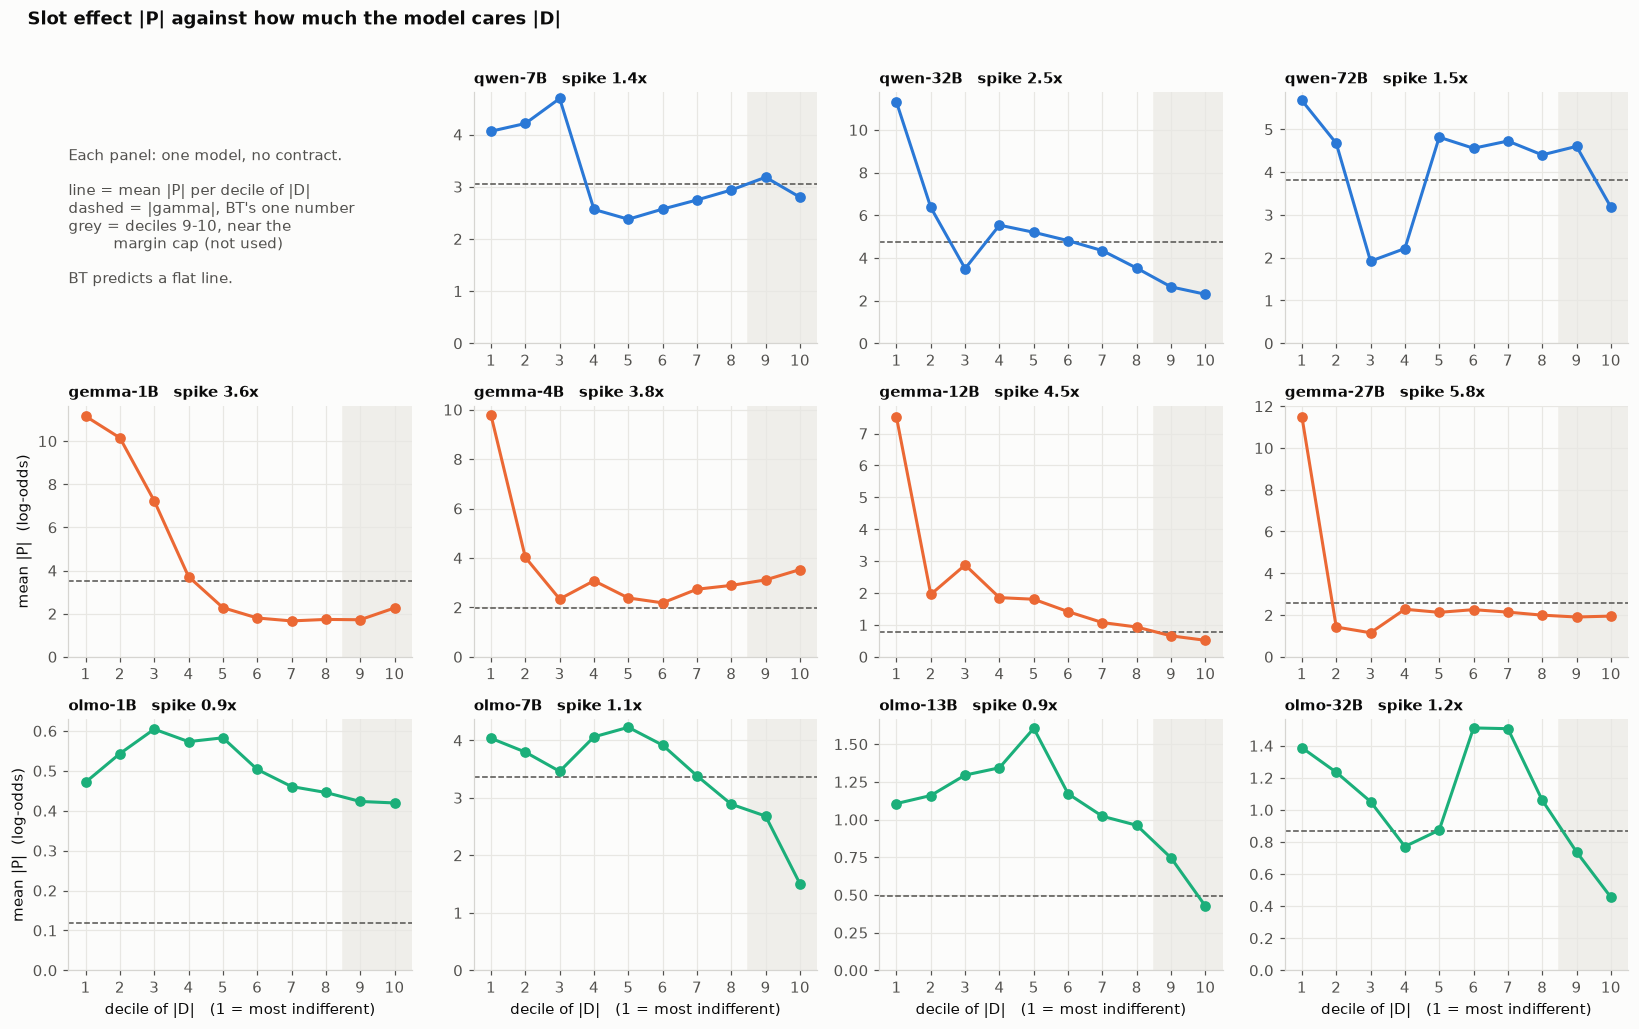

    model  gamma  P_dec1  P_mid  spike  ci_lo  ci_hi  rho_lowhalf
  qwen-7B  -3.05    4.06   2.98   1.36   1.15   1.60        -0.18
 qwen-32B  -4.73   11.30   4.48   2.52   2.29   2.73        -0.33
 qwen-72B  -3.81    5.67   3.77   1.50   1.37   1.62        -0.20
 gemma-1B   3.53   11.15   3.07   3.63   3.30   4.01        -0.62
 gemma-4B   1.99    9.77   2.60   3.76   3.50   3.97        -0.52
gemma-12B  -0.77    7.51   1.66   4.53   4.12   4.98        -0.47
gemma-27B  -2.59   11.49   1.99   5.77   4.82   6.74        -0.30
  olmo-1B   0.12    0.47   0.53   0.89   0.81   1.08         0.13
  olmo-7B   3.37    4.04   3.66   1.10   1.03   1.17         0.09
 olmo-13B  -0.50    1.11   1.23   0.90   0.81   0.99         0.17
 olmo-32B  -0.87    1.39   1.13   1.23   1.05   1.41        -0.13

spike CI above 1 in 9 of 11 aligned models.


In [4]:
fig, axes = plt.subplots(3, 4, figsize=(15, 9.5))
rows = []
for ax, m in zip(axes.flat, [None] + ALIGNED):
    if m is None:
        ax.axis("off"); continue
    p = PAIRS[m]
    prof = profile(p.aD.values, p.aP.values)
    g = p.P.mean()
    ax.axvspan(8.5, 10.5, color="#efeeea", zorder=0)
    ax.set_xlim(.5, 10.5)
    ax.plot(range(1, 11), prof, "-o", color=FAM_COLOR[m[0]], lw=2, ms=6, zorder=3)
    ax.axhline(abs(g), color=INK_MUTED, ls="--", lw=1)
    ax.set_ylim(0, None)
    ax.set_xticks(range(1, 11))
    lo, hi = boot_spike(p)
    s = spike(p.aD.values, p.aP.values)
    ax.set_title(f"{lbl(m)}   spike {s:.1f}x", loc="left", fontweight="bold", fontsize=9.5)
    rows.append(dict(model=lbl(m), gamma=g, P_dec1=prof[0], P_mid=prof[2:8].mean(),
                     spike=s, ci_lo=lo, ci_hi=hi,
                     rho_lowhalf=st.spearmanr(*p[p.aD <= p.aD.median()][["aD", "aP"]].values.T)[0]))
for ax in axes[:, 0]:
    ax.set_ylabel("mean |P|  (log-odds)")
for ax in axes[-1]:
    ax.set_xlabel("decile of |D|   (1 = most indifferent)")
axes[0, 0].text(0, .5, "Each panel: one model, no contract.\n\n"
                "line = mean |P| per decile of |D|\ndashed = |gamma|, BT's one number\n"
                "grey = deciles 9-10, near the\n         margin cap (not used)\n\n"
                "BT predicts a flat line.", fontsize=9.5, va="center", color=INK_MUTED)
fig.suptitle("Slot effect |P| against how much the model cares |D|",
             x=.02, ha="left", fontweight="bold")
fig.tight_layout(rect=[0, 0, 1, .97])
save(fig, "i1_slot_vs_indifference")
plt.show()

MAIN = pd.DataFrame(rows)
print(MAIN.round(2).to_string(index=False))
print(f"\nspike CI above 1 in {(MAIN.ci_lo > 1).sum()} of {len(MAIN)} aligned models.")

---
# Step 2 — three checks

| check | what it rules out |
|---|---|
| **cross-template** | $\lvert D\rvert$ from the other four templates, $\lvert P\rvert$ from this one. Rules out a mechanical link between $P$ and $D$, which are made from the same two numbers. |
| **same-look** | deciles of $\lvert D\rvert$ taken *within* pairs that differ in the same features. Rules out "the texts look alike, so the model can't tell them apart". |
| **per template** | the spike on each of the 5 templates alone. Rules out one odd template carrying the result. |

Also printed: **signed** $P$ in decile 1 against the middle, to see whether the model falls
back on its *usual* slot or a different one.

In [5]:
rows = []
for m in ALIGNED:
    p = PAIRS[m].copy()
    tot = p.groupby(["x", "y"]).D.transform("sum")
    p["aDx"] = ((tot - p.D) / 4).abs()                      # |D| from the other four templates
    q = deciles(p.aD.values)
    per_t = [spike(g.aD.values, g.aP.values) for _, g in p.groupby("t")]
    rows.append(dict(model=lbl(m),
                     spike=spike(p.aD.values, p.aP.values),
                     cross_template=spike(p.aDx.values, p.aP.values),
                     same_look=spike(p.aD.values, p.aP.values, groups=p.look.values),
                     templates_over_1_5=f"{sum(s > 1.5 for s in per_t)}/5",
                     per_template=" ".join(f"{s:.1f}" for s in per_t),
                     gamma=p.P.mean(), P_dec1_signed=p.P[q == 0].mean(),
                     P_mid_signed=p.P[(q >= 2) & (q <= 7)].mean()))
CHECKS = pd.DataFrame(rows)
print(CHECKS.round(2).to_string(index=False))

    model  spike  cross_template  same_look templates_over_1_5        per_template  gamma  P_dec1_signed  P_mid_signed
  qwen-7B   1.36            1.49       0.87                2/5 1.3 1.7 1.6 1.4 1.3  -3.05          -2.87         -2.96
 qwen-32B   2.52            2.37       1.80                5/5 2.3 2.2 2.8 2.6 2.2  -4.73         -11.03         -4.34
 qwen-72B   1.50            1.50       0.82                1/5 1.4 2.4 1.4 1.4 1.3  -3.81          -4.46         -3.65
 gemma-1B   3.63            2.33       3.87                4/5 5.2 1.1 4.1 5.2 5.5   3.53           8.82          2.33
 gemma-4B   3.76            2.71       1.58                5/5 3.4 3.8 3.8 3.5 3.0   1.99           1.67          1.85
gemma-12B   4.53            4.10       1.81                5/5 4.7 2.7 5.0 5.1 4.6  -0.77          -7.12         -0.15
gemma-27B   5.77            5.40       2.36                5/5 6.6 3.9 5.0 5.7 7.4  -2.59         -10.93         -1.73
  olmo-1B   0.89            1.11       1.44     

**Where in the pairs is the spike?** Within each "look" (which features differ), the Spearman
correlation between $\lvert D\rvert$ and $\lvert P\rvert$ — negative means H1 holds *inside* that
group of look-alike pairs. `B..` = brand only, `.S.` = screen only, `BSR` = all three, and so on.

In [6]:
LOOKS = ["B..", ".S.", "..R", "BS.", "B.R", ".SR", "BSR"]
tab = {}
for m in ALIGNED:
    p = PAIRS[m]
    tab[lbl(m)] = {lk: st.spearmanr(g.aD, g.aP)[0] for lk, g in p.groupby("look")}
LOOK_RHO = pd.DataFrame(tab).T[LOOKS]
print("Spearman rho(|D|, |P|) within each look:\n")
print(LOOK_RHO.round(2).to_string())
print("\nmedian |D| by look (how much the model cares, per group):\n")
print(pd.DataFrame({lbl(m): PAIRS[m].groupby("look").aD.median() for m in ALIGNED}).T[LOOKS]
      .round(1).to_string())

Spearman rho(|D|, |P|) within each look:

            B..   .S.   ..R   BS.   B.R   .SR   BSR
qwen-7B    0.17 -0.19  0.27  0.09 -0.04  0.19  0.36
qwen-32B  -0.73 -0.47 -0.40 -0.73 -0.87 -0.44 -0.68
qwen-72B  -0.32 -0.72 -0.43 -0.77 -0.06  0.05  0.16
gemma-1B  -0.71 -0.77 -0.45 -0.69 -0.21 -0.30 -0.18
gemma-4B  -0.78 -0.42  0.63 -0.58  0.56  0.52  0.25
gemma-12B -0.84  0.43 -0.18 -0.40 -0.53 -0.40 -0.32
gemma-27B -0.95  0.01  0.47 -0.66  0.05 -0.10 -0.37
olmo-1B    0.33  0.25  0.06  0.17  0.02 -0.13 -0.04
olmo-7B   -0.03 -0.26 -0.41 -0.21 -0.92 -0.67 -0.76
olmo-13B   0.01  0.26 -0.03  0.13 -0.31 -0.39 -0.37
olmo-32B   0.03 -0.29 -0.20 -0.14 -0.30 -0.13  0.00

median |D| by look (how much the model cares, per group):

look       B..   .S.   ..R   BS.   B.R   .SR   BSR
qwen-7B    1.8  10.0  21.4   5.4  21.2  19.3  18.8
qwen-32B   6.3  11.6  28.4   6.8  28.7  25.8  25.1
qwen-72B   3.1   9.3  21.9   6.8  20.3  18.6  17.9
gemma-1B   1.8   5.9  13.8   3.9  12.4  13.1  12.3
gemma-4B   5.5  11.

---
# Step 3 — base models

Same test on the base (pretrained) models. Their scores are raw log-probs, so $C = 0$.
gemma-pt is left out: it answers by slot on almost every pair, so it has no indifferent end
to compare.

In [7]:
rows = []
for m in BASE:
    p = PAIRS[m]
    tot = p.groupby(["x", "y"]).D.transform("sum")
    aDx = ((tot - p.D) / 4).abs().values
    lo, hi = boot_spike(p)
    prof = profile(p.aD.values, p.aP.values)
    rows.append(dict(model=lbl(m), gamma=p.P.mean(), P_dec1=prof[0], P_mid=prof[2:8].mean(),
                     spike=spike(p.aD.values, p.aP.values), ci_lo=lo, ci_hi=hi,
                     cross_template=spike(aDx, p.aP.values),
                     same_look=spike(p.aD.values, p.aP.values, groups=p.look.values)))
BASE_T = pd.DataFrame(rows)
print(BASE_T.round(2).to_string(index=False))

      model  gamma  P_dec1  P_mid  spike  ci_lo  ci_hi  cross_template  same_look
 qwen-pt-7B  -0.17    0.21   0.24   0.87   0.82   0.97            1.01       0.85
qwen-pt-32B   0.15    0.49   0.37   1.33   1.26   1.42            1.25       1.11
qwen-pt-72B   0.30    0.46   0.37   1.24   1.10   1.37            1.34       0.75
 olmo-pt-1B   0.13    0.37   0.32   1.16   1.11   1.22            1.03       1.16
 olmo-pt-7B   0.71    0.74   0.76   0.98   0.93   1.02            1.05       0.92
olmo-pt-13B   1.26    1.00   1.18   0.85   0.83   0.87            0.77       0.82
olmo-pt-32B   0.18    0.23   0.23   1.00   0.89   1.07            1.87       0.67


---
# Step 4 — Nir's version: contracts that make both laptops bad

Nir's question (2026-07-22): *if a contract makes both laptops very bad, is the slot bias between
them very strong? If one is clearly better, is it weak?*

In each contract run, every pair falls in one group:

| group | meaning | pairs per template (`8GB` / `14in+8GB`) |
|---|---|---|
| **both comply** | both laptops meet the contract | 105 / 10 |
| **one complies** | one meets it, one does not — "one is clearly better" | 450 / 200 |
| **both violate** | neither meets it — "both bad" | 435 / 780 |

Each pair is compared with **the same pair, same template, in the unconstrained run**, so the
pair itself is held fixed and only the contract changes. Top row: change in $\lvert D\rvert$ (did
the contract make the model more indifferent?). Bottom row: change in $\lvert P\rvert$ (did the
slot effect grow?). One dot per model; the bar is the mean over models.

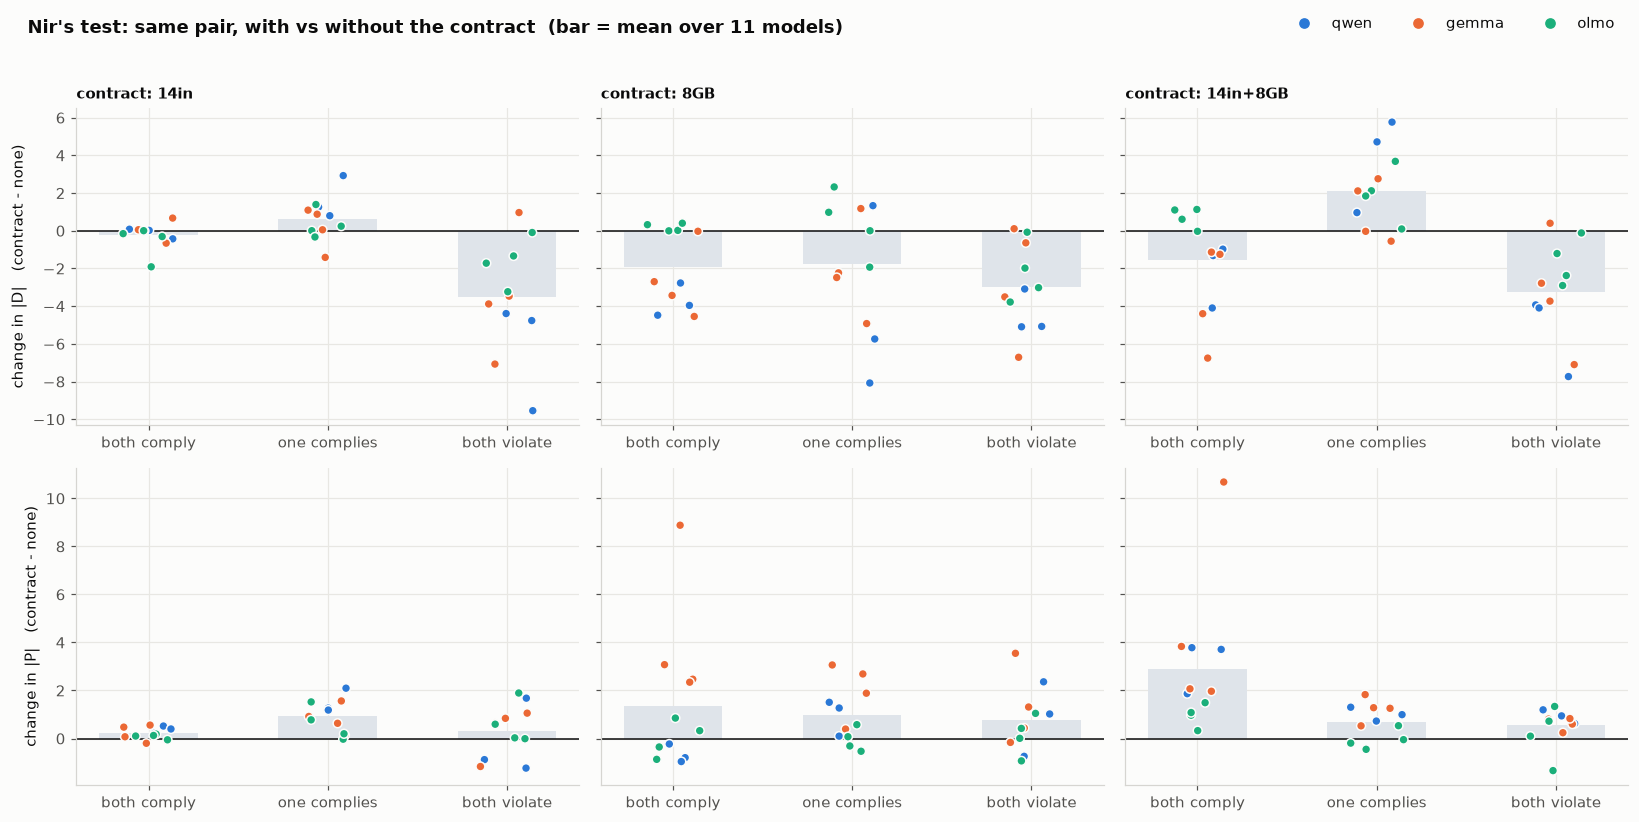

Mean over the 11 aligned models:

                            n    aD0     aD    dD   aP0    aP    dP
con      grp                                                       
14in     both comply    525.0  12.55  12.31 -0.24  2.76  2.98  0.22
         both violate  2175.0  11.88   8.38 -3.50  2.86  3.17  0.31
         one complies  2250.0  11.59  12.21  0.63  2.83  3.77  0.93
8GB      both comply    525.0   5.22   3.29 -1.93  3.13  4.47  1.34
         both violate  2175.0  10.76   7.77 -2.99  3.09  3.84  0.76
         one complies  2250.0  14.38  12.61 -1.78  2.52  3.50  0.97
14in+8GB both comply     50.0   3.94   2.39 -1.56  3.33  6.22  2.89
         both violate  3900.0  11.79   8.55 -3.24  2.89  3.44  0.55
         one complies  1000.0  12.34  14.48  2.13  2.59  3.30  0.71


In [8]:
def comply(items, cons):
    parts = np.array([s.split("|") for s in items])
    f = {"brand": parts[:, 0], "screen": parts[:, 1], "ram": parts[:, 2]}
    ok = np.ones(len(items), bool)
    for k, v in cons.items():
        ok &= f[k] == v
    return ok


GROUPS = ["both comply", "one complies", "both violate"]
rows, within = [], []
for m in ALIGNED:
    p0 = PAIRS[m].set_index(["x", "y", "t"])
    for con in CON[1:]:
        k = m + (con,)
        if k not in RUNS:
            continue
        j = pairs(RUNS[k], PMI_C[m]).set_index(["x", "y", "t"]).join(p0[["aD", "aP"]], rsuffix="0")
        cx = comply(j.index.get_level_values("x"), CONS[k])
        cy = comply(j.index.get_level_values("y"), CONS[k])
        j["grp"] = np.select([cx & cy, cx ^ cy], GROUPS[:2], GROUPS[2])
        j["dD"], j["dP"] = j.aD - j.aD0, j.aP - j.aP0
        within.append(dict(model=lbl(m), con=CLAB[con],
                           rho_dD_dP=st.spearmanr(j.dD, j.dP)[0]))
        for g_, g in j.groupby("grp"):
            rows.append(dict(model=lbl(m), fam=m[0], con=CLAB[con], grp=g_, n=len(g),
                             aD0=g.aD0.mean(), aD=g.aD.mean(), dD=g.dD.mean(),
                             aP0=g.aP0.mean(), aP=g.aP.mean(), dP=g.dP.mean()))
NIR = pd.DataFrame(rows)

fig, axes = plt.subplots(2, 3, figsize=(15, 7.5), sharey="row")
rng = np.random.default_rng(1)
for col, con in enumerate(["14in", "8GB", "14in+8GB"]):
    for row, (v, lab) in enumerate([("dD", "change in |D|   (contract - none)"),
                                    ("dP", "change in |P|   (contract - none)")]):
        ax = axes[row, col]
        sub = NIR[NIR.con == con]
        for gi, g_ in enumerate(GROUPS):
            t = sub[sub.grp == g_]
            ax.bar(gi, t[v].mean(), .55, color="#dfe4ea", zorder=2)
            ax.scatter(gi + rng.uniform(-.15, .15, len(t)), t[v], s=34, zorder=4,
                       color=[FAM_COLOR[f] for f in t.fam], edgecolor=SURFACE, lw=1)
        ax.axhline(0, color=INK, lw=1)
        ax.set_xticks(range(3), GROUPS)
        if col == 0:
            ax.set_ylabel(lab)
        if row == 0:
            ax.set_title(f"contract: {con}", loc="left", fontweight="bold", fontsize=10)
fig.legend(handles=[Line2D([], [], marker="o", ls="none", color=FAM_COLOR[f], label=f)
                    for f in FAM_COLOR], ncol=3, loc="upper right", frameon=False,
           bbox_to_anchor=(.99, 1.0))
fig.suptitle("Nir's test: same pair, with vs without the contract  (bar = mean over 11 models)",
             x=.02, ha="left", fontweight="bold")
fig.tight_layout(rect=[0, 0, 1, .96])
save(fig, "i2_nir_contract_groups")
plt.show()

print("Mean over the 11 aligned models:\n")
print(NIR.groupby(["con", "grp"], sort=False)[["n", "aD0", "aD", "dD", "aP0", "aP", "dP"]]
      .mean().round(2).to_string())

**The same test, pair by pair.** For every pair, the contract changes both how much the model
cares ($\Delta\lvert D\rvert$) and the slot effect ($\Delta\lvert P\rvert$). H1 predicts a
**negative** correlation: pairs the contract makes *more* indifferent should get a *bigger* slot
effect. This is the cleanest version of the test — the pair, the template and the text of the
two laptops are all held fixed; only the contract sentence moves.

In [9]:
W = pd.DataFrame(within).pivot(index="model", columns="con", values="rho_dD_dP")
W = W.reindex([lbl(m) for m in ALIGNED])[["14in", "8GB", "14in+8GB"]]
print("Spearman rho(change in |D|, change in |P|), all 4950 pairs per cell:\n")
print(W.round(2).to_string())
print(f"\nnegative (H1 direction) in {(W.values < 0).sum()} of {W.size} model x contract cells.")

Spearman rho(change in |D|, change in |P|), all 4950 pairs per cell:

con        14in   8GB  14in+8GB
model                          
qwen-7B    0.30  0.39      0.03
qwen-32B  -0.15 -0.46     -0.30
qwen-72B  -0.07 -0.27     -0.26
gemma-1B  -0.38 -0.47     -0.48
gemma-4B  -0.22 -0.44     -0.42
gemma-12B -0.62 -0.68     -0.56
gemma-27B -0.21 -0.67     -0.44
olmo-1B    0.24  0.12      0.27
olmo-7B   -0.26 -0.08      0.08
olmo-13B  -0.22 -0.36     -0.28
olmo-32B  -0.34 -0.37     -0.52

negative (H1 direction) in 26 of 33 model x contract cells.


---
## What this shows

**H1 holds in gemma and qwen-32B, weakly in qwen-7B/72B, and not in OLMo.**

| | spike | survives cross-template | survives same-look |
|---|---|---|---|
| gemma 1/4/12/27B | **3.6 – 5.8×** | yes (2.3 – 5.4×) | yes, smaller (1.6 – 3.9×) |
| qwen-32B | **2.5×** | yes (2.4×) | yes (1.8×) |
| qwen-7B / 72B | 1.4 / 1.5× | yes | **no** (0.9 / 0.8×) |
| olmo 1/7/13/32B | 0.9 – 1.2× | — | — |
| base models (qwen-pt, olmo-pt) | 0.85 – 1.33× | — | — |

- **Where it holds, it is large.** gemma-27B's slot effect on the 10% most indifferent pairs is
  11.5 log-odds, against about 2 everywhere else — more than its whole brand range (4.9) and
  screen range (6.8). On 5 of 5 templates.
- **The model falls back on its usual slot, much harder.** Signed $P$ in decile 1 has the same
  sign as $\gamma$ and is far larger than in the middle deciles: qwen-32B −11.0 vs −4.3,
  gemma-1B 8.8 vs 2.3, gemma-27B −10.9 vs −1.7, gemma-12B −7.1 vs −0.2. gemma-4B is the exception: its
  indifferent pairs go to *different* slots on different templates (big $\lvert P\rvert$, small signed mean).
- **Part of it is "look-alike", not "don't care".** Controlling for which features differ shrinks
  the spike by about half in most models, and removes it in qwen-7B/72B. Brand-only pairs carry the
  most: inside them alone, $\rho(\lvert D\rvert, \lvert P\rvert)$ is −0.71 to −0.95 in gemma and
  qwen-32B. So within pairs that look *equally* alike, the less the model cares, the more the
  slot decides — that part is indifference.
- **Not in the base models.** The pretrained preferences replicate (2026-08-16/18), but this
  behaviour does not: no base model spikes. It looks like something alignment adds.

**Nir's version: "both bad" is not what matters — indifference is.**

- *Both violate* pairs do **not** get a bigger slot effect than *one complies* pairs
  (Δ|P| +0.31 / +0.76 / +0.55 vs +0.93 / +0.97 / +0.71). Among bad laptops the model still has
  preferences (e.g. 16GB vs 4GB both break `8GB`), so it is not indifferent.
- The big jump is in **both comply** pairs under the double contract: they differ only in brand,
  the contract makes the model the most indifferent there (|D| 3.9 → 2.4), and |P| nearly doubles
  (3.3 → 6.2).
- **Pair by pair, the contract test supports H1**: the more a contract makes a pair indifferent,
  the more its slot effect grows — negative $\rho(\Delta\lvert D\rvert, \Delta\lvert P\rvert)$ in
  **26 of 33** model × contract cells. This includes olmo-13B/32B, which show no spike in Step 1.
- Every group's $\lvert P\rvert$ rises a little under any contract: a contract sentence makes the
  slot matter more overall.

**What it means for the method.** BT's single $\gamma$ is wrong for gemma and qwen-32B: the slot
effect is not one number, it depends on the pair. $D$ is still exact (it cancels any slot effect,
constant or not), so every position-corrected number we report is unaffected. Anything that
uses the fitted $\gamma$ as *the* bias — e.g. "$\gamma$ beats the brand range" (deck 5, Fig 12.1)
— understates the bias on indifferent pairs and overstates it on decisive ones.

**Open.**
- The same-look check over-controls a little (brand-only pairs are *also* the most indifferent), so
  the true indifference share is between the two columns.
- OLMo: no spike in the unconstrained runs, but the contract test agrees with H1 for 13B/32B. Not
  resolved.
- The confound from the label scheme (slot A = token "1") is still there: "falls back on slot A"
  and "falls back on the answer 1" cannot be told apart with this data.